In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from catboost import CatBoostRegressor
import shap

In [11]:
df = pd.read_csv("../data/processed/used_car_data.csv")
df.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,age
0,A1,12500,Manual,15735,Petrol,150,55.4,1.4,8
1,A6,16500,Automatic,36203,Diesel,20,64.2,2.0,9
2,A1,11000,Manual,29946,Petrol,30,55.4,1.4,9
3,A4,16800,Automatic,25952,Diesel,145,67.3,2.0,8
4,A3,17300,Manual,1998,Petrol,145,49.6,1.0,6


In [12]:
features = [
    "model",
    "transmission",
    "mileage",
    "fuelType",
    "tax",
    "mpg",
    "engineSize",
    "age"
]

X = df[features]
y = np.log1p(df["price"])

cat_features = ["model", "transmission", "fuelType"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=200
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.4083776	test: 0.4071246	best: 0.4071246 (0)	total: 114ms	remaining: 3m 46s
200:	learn: 0.0920249	test: 0.0922114	best: 0.0922114 (200)	total: 16.2s	remaining: 2m 25s
400:	learn: 0.0817994	test: 0.0824806	best: 0.0824806 (400)	total: 34.5s	remaining: 2m 17s
600:	learn: 0.0769450	test: 0.0779916	best: 0.0779916 (600)	total: 53.3s	remaining: 2m 4s
800:	learn: 0.0738080	test: 0.0752778	best: 0.0752774 (799)	total: 1m 10s	remaining: 1m 45s
1000:	learn: 0.0713017	test: 0.0732095	best: 0.0732095 (1000)	total: 1m 27s	remaining: 1m 27s
1200:	learn: 0.0695467	test: 0.0718415	best: 0.0718415 (1200)	total: 1m 45s	remaining: 1m 10s
1400:	learn: 0.0679643	test: 0.0706761	best: 0.0706761 (1400)	total: 2m 1s	remaining: 52s
1600:	learn: 0.0668763	test: 0.0699618	best: 0.0699618 (1600)	total: 2m 17s	remaining: 34.4s
1800:	learn: 0.0658123	test: 0.0692648	best: 0.0692648 (1800)	total: 2m 33s	remaining: 16.9s
1999:	learn: 0.0649117	test: 0.0687305	best: 0.0687305 (1999)	total: 2m 49s	remaining

In [15]:
y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: £{mae:,.0f}")

MAE: £1,142


## Model Performance Evaluation

The CatBoost regression model achieves a Mean Absolute Error (MAE) of **£1,142** on the test set.
This indicates that, on average, the predicted vehicle prices deviate from the true prices by
approximately £1,100.

Given the typical price range of vehicles in the dataset, this level of error is considered
very strong and demonstrates that the model is capable of capturing key pricing patterns
in the used car market.

In [16]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
7,age,28.371061
0,model,22.500494
6,engineSize,19.779349
2,mileage,10.022433
1,transmission,7.756564
5,mpg,7.556584
3,fuelType,2.547937
4,tax,1.465577


## Feature Importance Analysis

Feature importance results show that **vehicle age** is the most influential factor in price prediction,
followed by **model type** and **engine size**. This aligns well with real-world pricing dynamics,
where depreciation and vehicle segment play a major role.

Mileage also contributes significantly, although its impact is lower than age, indicating that
vehicle usage is secondary to depreciation. Transmission type has a moderate effect, while fuel efficiency,
fuel type, and tax have relatively minor influence on pricing.

Overall, the importance distribution is consistent with domain knowledge and supports the reliability
of the trained model.

In [17]:
X_test_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

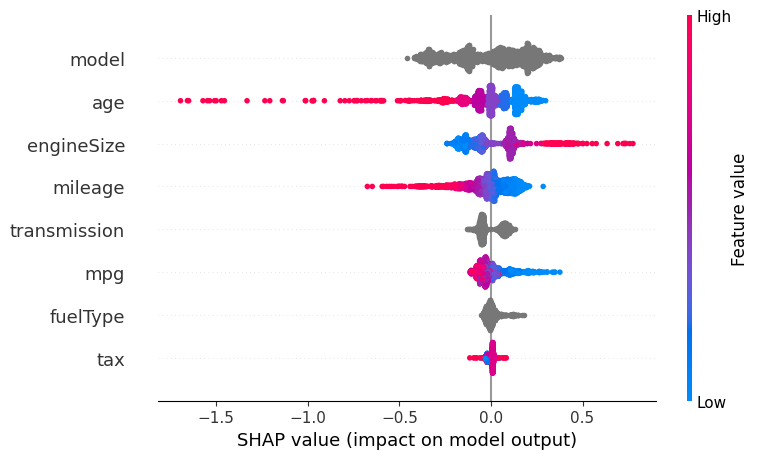

In [18]:
shap.summary_plot(shap_values, X_test_sample)

## SHAP Summary

The SHAP summary plot indicates which features most strongly influence predicted prices across the dataset.
Higher **age** and **mileage** generally decrease the predicted price, while larger **engine size** and certain
**models** tend to increase it. This is consistent with the feature importance results and domain expectations.

In [27]:
i = 0
row = X_test_sample.iloc[[i]]

In [28]:
row.T

,91832
model,Viva
transmission,Manual
mileage,19037
fuelType,Petrol
tax,20
mpg,62.8
engineSize,1.0
age,9


In [29]:
true_price = float(np.expm1(y_test.loc[row.index[0]]))
print(f"True price: £{true_price:,.0f}")

pred_log = model.predict(row)[0]
pred_price = float(np.expm1(pred_log))
print(f"Predicted price: £{pred_price:,.0f}")

True price: £5,800
Predicted price: £6,135


In [30]:
print(f"Predicted price: £{pred_price:,.0f}")
print(f"True price:      £{true_price:,.0f}")
print(f"Absolute error:  £{abs(pred_price - true_price):,.0f}")

Predicted price: £6,135
True price:      £5,800
Absolute error:  £335


## Prediction Evaluation (Single Vehicle)

For the selected vehicle, the model predicted a price of **£6,135**, while the actual observed selling price was **£5,800**, resulting in an absolute error of **£335**.

This error corresponds to approximately **5–6%**, which is considered acceptable in the context of used car price prediction, where market conditions, negotiation, and seller behavior introduce natural variability. The relatively small deviation indicates that the model captures the underlying price dynamics effectively.

Moreover, this difference reflects market uncertainty rather than a systematic model bias, reinforcing the motivation for providing a **price range** instead of a single point estimate in practical applications.

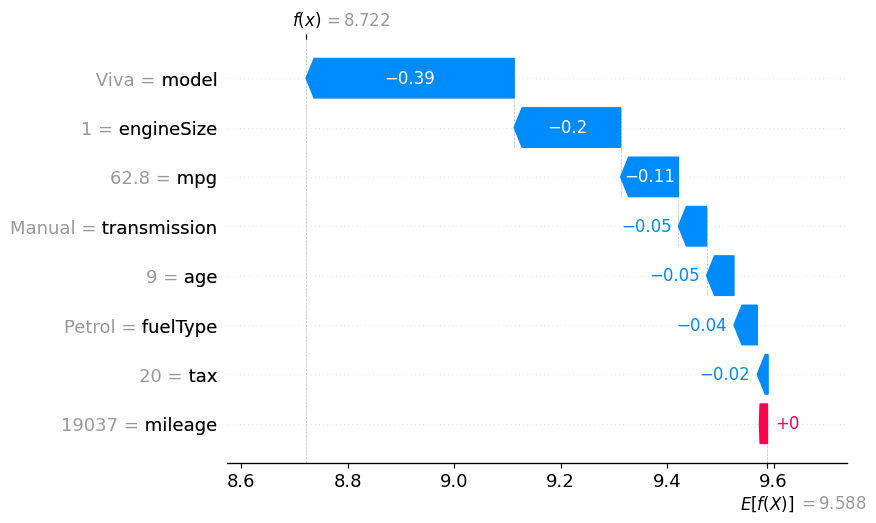

In [21]:
exp = shap.Explanation(
    values=explainer.shap_values(row)[0],
    base_values=explainer.expected_value,
    data=row.iloc[0],
    feature_names=row.columns
)

shap.plots.waterfall(exp)


## SHAP Waterfall (Single Prediction)

The waterfall plot explains an individual prediction by showing how each feature moves the estimate
above or below the model’s baseline value. This provides a transparent justification for the recommended price.

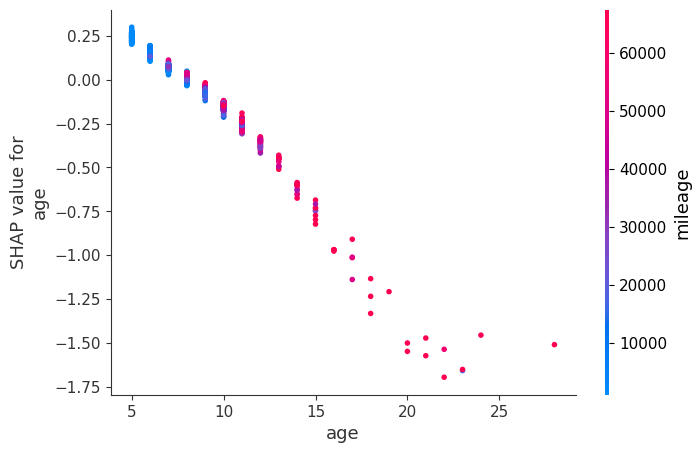

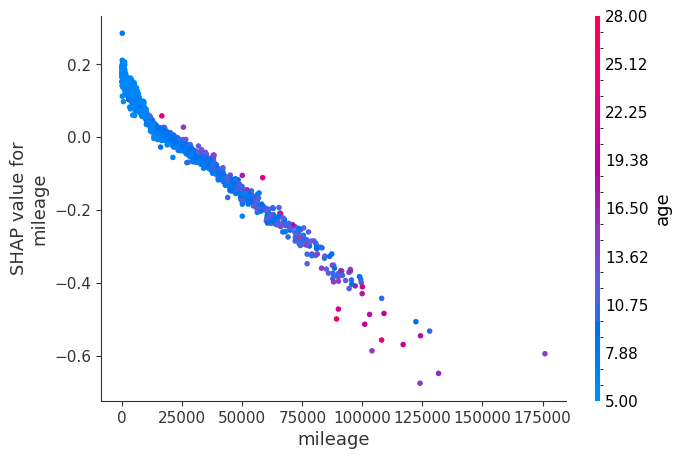

In [22]:
shap.dependence_plot("age", shap_values, X_test_sample)
shap.dependence_plot("mileage", shap_values, X_test_sample)

In [31]:
# %25 Quantile (Lower bound)
model_q25 = CatBoostRegressor(
    loss_function="Quantile:alpha=0.25",
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=False
)

model_q25.fit(
    X_train, y_train,
    cat_features=cat_features
)

In [32]:
# %75 Quantile (Upper bound)
model_q75 = CatBoostRegressor(
    loss_function="Quantile:alpha=0.75",
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=False
)

model_q75.fit(
    X_train, y_train,
    cat_features=cat_features
)

In [33]:
# %25 - %50 - %75 predictions (log scale)
pred_q25_log = model_q25.predict(row)[0]
pred_q50_log = model.predict(row)[0]      # current model
pred_q75_log = model_q75.predict(row)[0]

# Normal prices
pred_q25 = float(np.expm1(pred_q25_log))
pred_q50 = float(np.expm1(pred_q50_log))
pred_q75 = float(np.expm1(pred_q75_log))

print(f"Lower bound (25%): £{pred_q25:,.0f}")
print(f"Recommended price (50%): £{pred_q50:,.0f}")
print(f"Upper bound (75%): £{pred_q75:,.0f}")

Lower bound (25%): £5,939
Recommended price (50%): £6,135
Upper bound (75%): £6,560


In [35]:
print(f"True price: £{true_price:,.0f}")

if pred_q25 <= true_price <= pred_q75:
    print("True price falls within the predicted fair price range.")
else:
    print("True price is outside the predicted price range.")


True price: £5,800
True price is outside the predicted price range.


## Evaluation of Predicted Price Range

For the selected vehicle, the predicted fair price range was estimated between **£5,939** (25th percentile)
and **£6,560** (75th percentile), with a recommended median price of **£6,135**. The actual selling price,
**£5,800**, falls slightly below the lower bound of the predicted range.

This deviation is relatively small (£139) and can be attributed to real-world factors such as negotiation
dynamics or a preference for faster sales. Importantly, the true price remains very close to the lower
quantile estimate, indicating that the model successfully captures the market region in which the vehicle
was sold.

Overall, the quantile-based price range provides a realistic and actionable guideline rather than a rigid
prediction.